In [2]:
import numpy as np
import pandas as pd

In [3]:
filenames = ['TWIST_T0_cleaned.csv',
             'TWIST_T0_100.counts',
             'TWIST_T0_10.counts',
             'TWIST_T0_1.counts',
             'TWIST_T0_01.counts',
             'IAKOV_83_S7_R1_001.counts','IAKOV_83_S7_R2_001.counts',
             'IAKOV_84_S8_R1_001.counts','IAKOV_84_S8_R2_001.counts',
             'IAKOV_85_S9_R1_001.counts','IAKOV_85_S9_R2_001.counts',
             'IAKOV_86_S10_R1_001.counts','IAKOV_86_S10_R2_001.counts',
             'IAKOV_83_S7_R1_001_0.05.counts','83_S7_R1_001_0.005.counts',
             'IAKOV_84_S8_R1_001_0.05.counts','84_S8_R1_001_0.005.counts',
             'IAKOV_85_S9_R1_001_0.05.counts','85_S9_R1_001_0.005.counts',
             'IAKOV_86_S10_R1_001_0.05.counts','86_S10_R1_001_0.005.counts']

N_emps = np.array([10,100,10,1,0.1,100,100,10,10,1,1,0.1,0.1,100,100,10,10,1,1,0.1,0.1]) * 1.1e8

df = pd.DataFrame()
df['filename'] = filenames
df['N_emp'] = N_emps

In [4]:
for i in range(len(df)):

    #read the file
    if df.loc[i,'filename'][-1] == 'v':
        data = pd.read_csv('/home/tommaso/new_phd/data_raw/%s'%df.loc[i,'filename'],delimiter=',',index_col=0)
    else:
        data = pd.read_csv('/home/tommaso/new_phd/data_raw/%s'%df.loc[i,'filename'],delimiter=' ', names=['seq','T0'],index_col=0)

    #compute quantities
    df.loc[i,'D'] = int(data['T0'].sum())
    df.loc[i,'count2_sum'] = int((data['T0']**2).sum())
    df.loc[i,'unique_seqs'] = int(len(data))

    #for chao1
    df.loc[i,'f1'] = len(data.query('T0 == 1'))
    df.loc[i,'f2'] = len(data.query('T0 == 2'))

    print('Done %s'%df.loc[i,'filename'])

Done TWIST_T0_cleaned.csv
Done TWIST_T0_100.counts
Done TWIST_T0_10.counts
Done TWIST_T0_1.counts
Done TWIST_T0_01.counts
Done IAKOV_83_S7_R1_001.counts
Done IAKOV_83_S7_R2_001.counts
Done IAKOV_84_S8_R1_001.counts
Done IAKOV_84_S8_R2_001.counts
Done IAKOV_85_S9_R1_001.counts
Done IAKOV_85_S9_R2_001.counts
Done IAKOV_86_S10_R1_001.counts
Done IAKOV_86_S10_R2_001.counts
Done IAKOV_83_S7_R1_001_0.05.counts
Done 83_S7_R1_001_0.005.counts
Done IAKOV_84_S8_R1_001_0.05.counts
Done 84_S8_R1_001_0.005.counts
Done IAKOV_85_S9_R1_001_0.05.counts
Done 85_S9_R1_001_0.005.counts
Done IAKOV_86_S10_R1_001_0.05.counts
Done 86_S10_R1_001_0.005.counts


import seaborn as sns
for i in range(len(fields_array)):
    sns.heatmap(fields_array[i], vmin = np.log(0.5/20), vmax = np.log(2/20))
    plt.show()

In [13]:
df['F_all'] =  (df['count2_sum']/df['D'] - df['D']/(20**7) - 1)
df['Q_threshold'] = [0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.05,0.005,0.05,0.005,0.05,0.005,0.05,0.005]
df['label'] = ['original_TwistT0','pre-seq','pre-seq','pre-seq','pre-seq','forward-seq','reverse-seq','forward-seq','reverse-seq','forward-seq','reverse-seq','forward-seq','reverse-seq','forward-seq Q_thresh = 0.05','forward-seq Q_thresh = 0.005','forward-seq Q_thresh = 0.05','forward-seq Q_thresh = 0.005','forward-seq Q_thresh = 0.05','forward-seq Q_thresh = 0.005','forward-seq Q_thresh = 0.05','forward-seq Q_thresh = 0.005']
df.to_csv('df.csv')
#df_sel

In [10]:
df['F.F.-1 = D/N_emp'] = df['D'] / df['N_emp']
df['F.F.-1 = count2_sum/D - D/20**7 - 1'] = df['count2_sum']/df['D'] -  df['D'] /(20**7) - 1
df['D/N_emp'] = df['D'] / df['N_emp']


/tmp/ipykernel_1607126/3115441237.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sel['F.F.-1 = D/N_emp'] = df_sel['D'] / df_sel['N_emp']
/tmp/ipykernel_1607126/3115441237.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sel['F.F.-1 = count2_sum/D - D/20**7 - 1'] = df_sel['count2_sum']/df_sel['D'] -  df_sel['D'] /(20**7) - 1
/tmp/ipykernel_1607126/3115441237.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

,filename,N_emp,D,count2_sum,unique_seqs,label,F.F.-1 = D/N_emp,F.F.-1 = count2_sum/D - D/20**7 - 1,D/N_emp
0,TWIST_T0_cleaned.csv,1.100000e+09,240537189.0,1.006635e+09,98468089.0,original_TwistT0,0.218670,2.997025,0.218670
1,TWIST_T0_100.counts,1.100000e+10,270877.0,2.875590e+05,262765.0,pre-seq,0.000025,0.061374,0.000025
2,TWIST_T0_10.counts,1.100000e+09,139501.0,1.474130e+05,135674.0,pre-seq,0.000127,0.056607,0.000127
3,TWIST_T0_1.counts,1.100000e+08,131784.0,1.413900e+05,127154.0,pre-seq,0.001198,0.072789,0.001198
4,TWIST_T0_01.counts,1.100000e+07,90990.0,1.134680e+05,80864.0,pre-seq,0.008272,0.246967,0.008272
5,IAKOV_83_S7_R1_001.counts,1.100000e+10,3087107.0,3.214887e+06,3025212.0,forward-seq,0.000281,0.038980,0.000281
6,IAKOV_83_S7_R2_001.counts,1.100000e+10,5329095.0,5.695323e+06,5155047.0,reverse-seq,0.000484,0.064559,0.000484
7,IAKOV_84_S8_R1_001.counts,1.100000e+09,1042054.0,1.079956e+06,1023704.0,forward-seq,0.000947,0.035558,0.000947
8,IAKOV_84_S8_R2_001.counts,1.100000e+09,1757721.0,1.860845e+06,1708776.0,reverse-seq,0.001598,0.057296,0.001598
9,IAKOV_85_S9_R1_001.counts,1.100000e+08,1225262.0,1.491882e+06,1104308.0,forward-seq,0.011139,0.216645,0.011139


[]

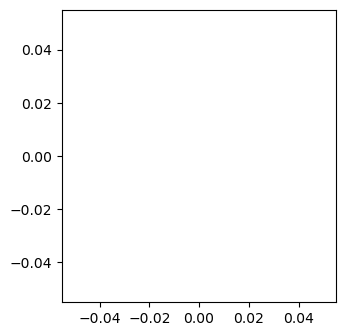

In [11]:
plt.figure(figsize=(12,3.8), facecolor='white')

ax = plt.subplot(1,3,1)
for a, df

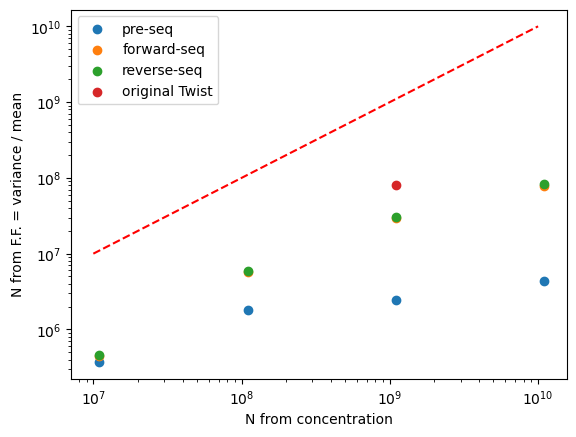

In [392]:
M = float(20**7)
df_sel['F_all'] = (df_sel['count2_sum']/df_sel['D'] - df_sel['D']/M - 1)

plt.scatter(df_sel.iloc[1:5]['N_emp'], df_sel.iloc[1:5]['D'] /  df_sel.iloc[1:5]['F_all'], label='pre-seq')
plt.scatter(df_sel.iloc[[5,7,9,11]]['N_emp'], df_sel.iloc[[5,7,9,11]]['D'] /  df_sel.iloc[[5,7,9,11]]['F_all'],label='forward-seq')
plt.scatter(df_sel.iloc[[6,8,10,12]]['N_emp'], df_sel.iloc[[6,8,10,12]]['D'] /  df_sel.iloc[[6,8,10,12]]['F_all'], label='reverse-seq')
plt.scatter(df_sel.iloc[0]['N_emp'], df_sel.iloc[0]['D'] /  df_sel.iloc[0]['F_all'], label='original Twist')

#plt.scatter(df_sel.iloc[13:]['N_emp'], df_sel.iloc[13:]['D'] /  df_sel.iloc[13:]['F_all'],label='forward-seq Q_thre=0.05', color='C1', marker='x')

plt.plot([1e7,1e10],[1e7,1e10], color='red', linestyle='--')
plt.xlabel('N from concentration')
plt.ylabel('N from F.F. = variance / mean')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.title('')

plt.savefig('N_comparison.png')

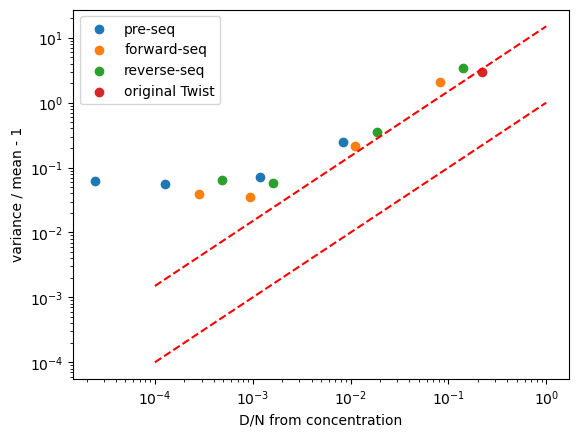

In [410]:
M = float(20**7)
df_sel['F_all'] = (df_sel['count2_sum']/df_sel['D'] - df_sel['D']/M - 1)

plt.scatter(df_sel.iloc[1:5]['D']/df_sel.iloc[1:5]['N_emp'],   df_sel.iloc[1:5]['F_all'], label='pre-seq')
plt.scatter(df_sel.iloc[[5,7,9,11]]['D']/df_sel.iloc[[5,7,9,11]]['N_emp']  ,df_sel.iloc[[5,7,9,11]]['F_all'],label='forward-seq')
plt.scatter(df_sel.iloc[[6,8,10,12]]['D'] /df_sel.iloc[[6,8,10,12]]['N_emp'], df_sel.iloc[[6,8,10,12]]['F_all'], label='reverse-seq')
plt.scatter(df_sel.iloc[0]['D']/df_sel.iloc[0]['N_emp'],  df_sel.iloc[0]['F_all'], label='original Twist')

#plt.scatter(df_sel.iloc[13:]['D'] / df_sel.iloc[13:]['N_emp'],  df_sel.iloc[13:]['F_all'],label='forward-seq Q_thre=0.05', color='C1', marker='x')

plt.plot([1e-4,1e0],[1e-4,1e0], color='red', linestyle='--')
plt.plot([1e-4,1e0],[15e-4,15e0], color='red', linestyle='--')
plt.xlabel('D/N from concentration')
plt.ylabel('variance / mean - 1')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.title('')
plt.savefig('F_comparison.png')

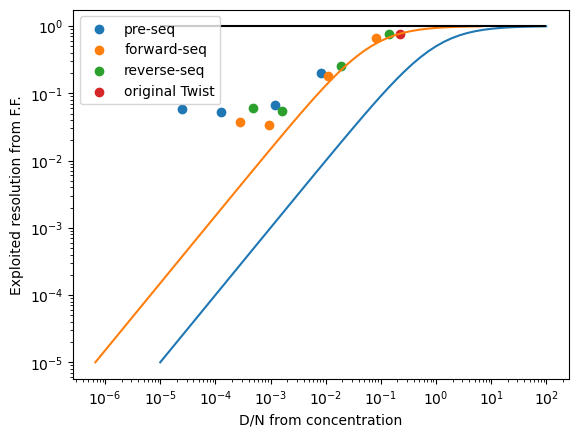

In [411]:
M = float(20**7)
df_sel['F_all'] = (df_sel['count2_sum']/df_sel['D'] - df_sel['D']/M - 1)

plt.scatter(df_sel.iloc[1:5]['D']/df_sel.iloc[1:5]['N_emp'],   df_sel.iloc[1:5]['F_all'] / (1 + df_sel.iloc[1:5]['F_all'] ), label='pre-seq')
plt.scatter(df_sel.iloc[[5,7,9,11]]['D']/df_sel.iloc[[5,7,9,11]]['N_emp']  ,df_sel.iloc[[5,7,9,11]]['F_all'] / (1+df_sel.iloc[[5,7,9,11]]['F_all']),label='forward-seq')
plt.scatter(df_sel.iloc[[6,8,10,12]]['D'] /df_sel.iloc[[6,8,10,12]]['N_emp'], df_sel.iloc[[6,8,10,12]]['F_all'] / (1+df_sel.iloc[[6,8,10,12]]['F_all']), label='reverse-seq')
plt.scatter(df_sel.iloc[0]['D']/df_sel.iloc[0]['N_emp'],  df_sel.iloc[0]['F_all']/(1+df_sel.iloc[0]['F_all']), label='original Twist')

x = np.logspace(-5,2)
y = x / (1+x)
plt.plot(x,y)
plt.plot(x / 15,y)
plt.hlines(0.99,1e-5,1e2,color='black')
#plt.scatter(df_sel.iloc[13:]['D'] / df_sel.iloc[13:]['N_emp'],  df_sel.iloc[13:]['F_all'],label='forward-seq Q_thre=0.05', color='C1', marker='x')

#plt.plot([1e-4,1e0],[1e-4,1e0], color='red', linestyle='--')
plt.xlabel('D/N from concentration')
plt.ylabel('Exploited resolution from F.F.')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.title('')
plt.savefig('F_comparison.png')

Text(0.5, 1.0, '')

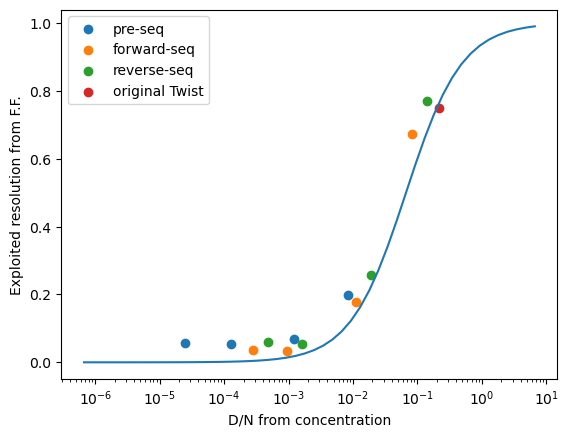

In [406]:
M = float(20**7)
df_sel['F_all'] = (df_sel['count2_sum']/df_sel['D'] - df_sel['D']/M - 1)

plt.scatter(df_sel.iloc[1:5]['D']/df_sel.iloc[1:5]['N_emp'],   df_sel.iloc[1:5]['F_all'] / (1 + df_sel.iloc[1:5]['F_all'] ), label='pre-seq')
plt.scatter(df_sel.iloc[[5,7,9,11]]['D']/df_sel.iloc[[5,7,9,11]]['N_emp']  ,df_sel.iloc[[5,7,9,11]]['F_all'] / (1+df_sel.iloc[[5,7,9,11]]['F_all']),label='forward-seq')
plt.scatter(df_sel.iloc[[6,8,10,12]]['D'] /df_sel.iloc[[6,8,10,12]]['N_emp'], df_sel.iloc[[6,8,10,12]]['F_all'] / (1+df_sel.iloc[[6,8,10,12]]['F_all']), label='reverse-seq')
plt.scatter(df_sel.iloc[0]['D']/df_sel.iloc[0]['N_emp'],  df_sel.iloc[0]['F_all']/(1+df_sel.iloc[0]['F_all']), label='original Twist')

x = np.logspace(-5,2)
y = x / (1+x)
plt.plot(x / 15,y)
#plt.scatter(df_sel.iloc[13:]['D'] / df_sel.iloc[13:]['N_emp'],  df_sel.iloc[13:]['F_all'],label='forward-seq Q_thre=0.05', color='C1', marker='x')

#plt.plot([1e-4,1e0],[1e-4,1e0], color='red', linestyle='--')
plt.xlabel('D/N from concentration')
plt.ylabel('Exploited resolution from F.F.')
plt.xscale('log')
#plt.yscale('log')
plt.legend()
plt.title('')

In [398]:
df_sel[']

,filename,N_emp,D,count2_sum,unique_seqs,Q_threshold,F.F.-1 = D/N_emp,F.F.-1 = count2_sum/D - D/20**7 - 1,F_all
0,TWIST_T0_cleaned.csv,1.100000e+09,240537189.0,1.006635e+09,98468089.0,0.1,0.218670,2.997025,2.997025
1,TWIST_T0_100.counts,1.100000e+10,270877.0,2.875590e+05,262765.0,0.1,0.000025,0.061374,0.061374
2,TWIST_T0_10.counts,1.100000e+09,139501.0,1.474130e+05,135674.0,0.1,0.000127,0.056607,0.056607
3,TWIST_T0_1.counts,1.100000e+08,131784.0,1.413900e+05,127154.0,0.1,0.001198,0.072789,0.072789
4,TWIST_T0_01.counts,1.100000e+07,90990.0,1.134680e+05,80864.0,0.1,0.008272,0.246967,0.246967
5,IAKOV_83_S7_R1_001.counts,1.100000e+10,3087107.0,3.214887e+06,3025212.0,0.1,0.000281,0.038980,0.038980
6,IAKOV_83_S7_R2_001.counts,1.100000e+10,5329095.0,5.695323e+06,5155047.0,0.1,0.000484,0.064559,0.064559
7,IAKOV_84_S8_R1_001.counts,1.100000e+09,1042054.0,1.079956e+06,1023704.0,0.1,0.000947,0.035558,0.035558
8,IAKOV_84_S8_R2_001.counts,1.100000e+09,1757721.0,1.860845e+06,1708776.0,0.1,0.001598,0.057296,0.057296
9,IAKOV_85_S9_R1_001.counts,1.100000e+08,1225262.0,1.491882e+06,1104308.0,0.1,0.011139,0.216645,0.216645


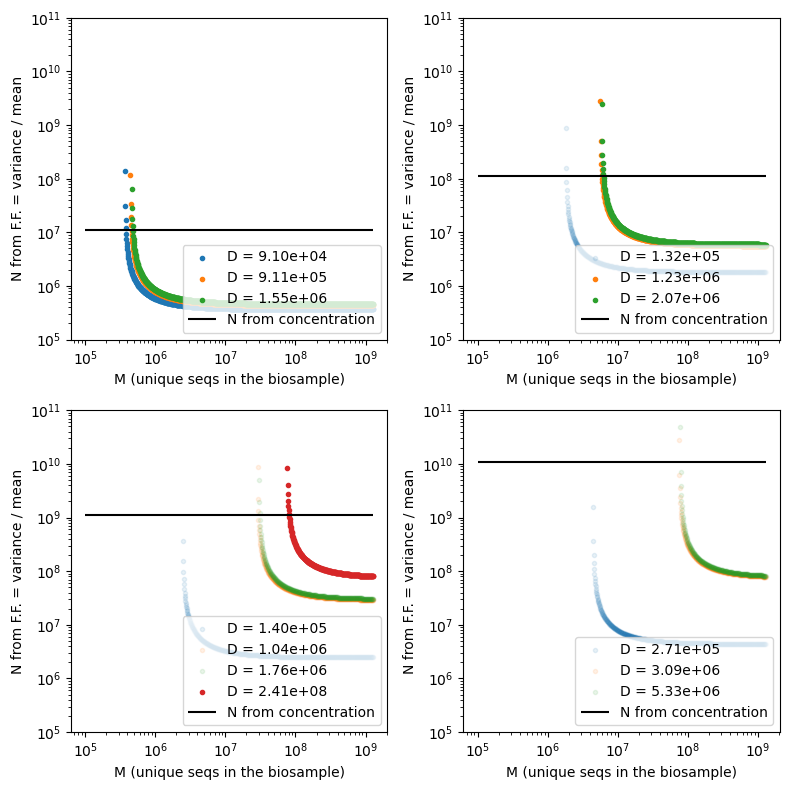

In [386]:
jj = 0
plt.figure(figsize=(8,8),facecolor='white')
for N_emp in [1.1e7,1.1e8,1.1e9,1.1e10]:
    plt.subplot(2,2,jj+1)
    df_sel_sel = df_sel.iloc[:13].query('N_emp == %s'%N_emp).sort_values('D')
    for i in range(len(df_sel_sel)):
        series = df_sel_sel.iloc[i]
        x = np.logspace(5,np.log10(float(20**7)),1000)
        if (df_sel_sel.iloc[i,-1] > 0.1):
            plt.scatter(x, series['D'] / (series['count2_sum'] / series['D']- series['D']/x -1), marker='.', label='D = %.2e'%series['D'])
        else:
            plt.scatter(x, series['D'] / (series['count2_sum'] / series['D']- series['D']/x -1), marker='.', label='D = %.2e'%series['D'], alpha=0.1)
    plt.hlines(N_emp,1e5,float(20**7),color='black', label= 'N from concentration')
    plt.xlabel('M (unique seqs in the biosample)')
    plt.ylabel('N from F.F. = variance / mean')
    plt.xscale('log')
    plt.yscale('log')
    plt.ylim(1e5,1e11)
    plt.legend(loc=4)
    jj += 1

plt.tight_layout()
plt.savefig('M_dependence.png')

Text(0.5, 0, 'M')

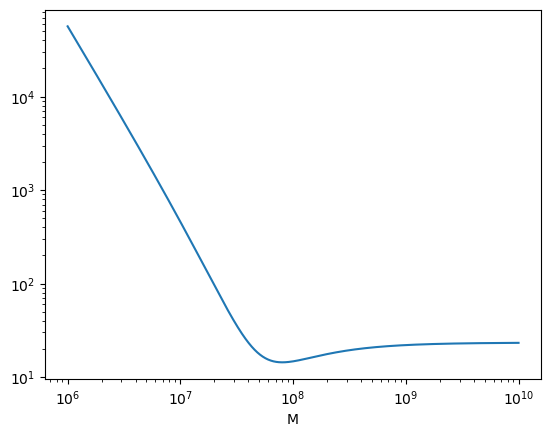

In [277]:
def mse_F(M):
    mse_ = np.zeros(len(M))
    for i in range(len(df)):
        F_emp = df.loc[i,'D']/df.loc[i,'N_emp'] 
        F_theo = (df.loc[i,'count2_sum']/df.loc[i,'D'] - df.loc[i,'D']/M - 1)
        #print(N_emp, N_theo)
        mse_ = mse_ + (F_emp - F_theo)**2
    return mse_

M_array = np.logspace(6,10,1000)
plt.loglog(M_array, mse_F(M_array))
M_opt = M_array[np.argmin(mse_F(M_array))]
plt.xlabel('M')

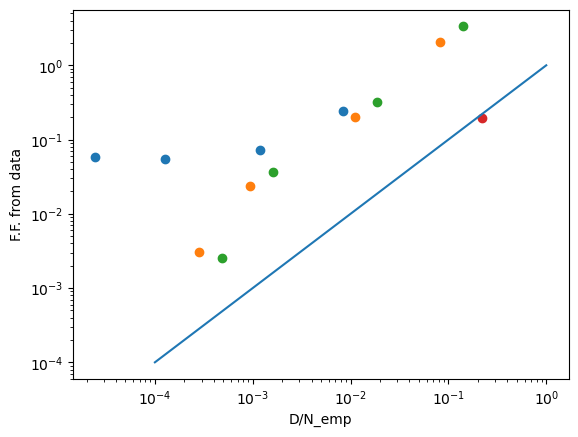

In [278]:
M = M_opt
df_sel['F_all'] = (df_sel['count2_sum']/df_sel['D'] - df_sel['D']/M - 1)

plt.scatter(df_sel.iloc[1:5]['D']/df_sel.iloc[1:5]['N_emp'],   df_sel.iloc[1:5]['F_all'])
plt.scatter(df_sel.iloc[[5,7,9,11]]['D']/df_sel.iloc[[5,7,9,11]]['N_emp']  ,df_sel.iloc[[5,7,9,11]]['F_all'])
plt.scatter(df_sel.iloc[[6,8,10,12]]['D'] /df_sel.iloc[[6,8,10,12]]['N_emp'], df_sel.iloc[[6,8,10,12]]['F_all'])
plt.scatter(df_sel.iloc[0]['D']/df_sel.iloc[0]['N_emp'],  df_sel.iloc[0]['F_all'])

plt.plot([1e-4,1e0],[1e-4,1e0])
plt.xlabel('D/N_emp')
Skip to Main
experimental_verification
Last Checkpoint: last month
[Python 3 (ipykernel)]
Selection deleted
M = float(20**7)
df_sel['F_all'] = (df_sel['count2_sum']/df_sel['D'] - df_sel['D']/M - 1)

plt.scatter(df_sel.iloc[1:5]['D']/df_sel.iloc[1:5]['N_emp'],   df_sel.iloc[1:5]['F_all'])
plt.scatter(df_sel.iloc[[5,7,9,11]]['D']/df_sel.iloc[[5,7,9,11]]['N_emp']  ,df_sel.iloc[[5,7,9,11]]['F_all'])
plt.scatter(df_sel.iloc[[6,8,10,12]]['D'] /df_sel.iloc[[6,8,10,12]]['N_emp'], df_sel.iloc[[6,8,10,12]]['F_all'])
plt.scatter(df_sel.iloc[0]['D']/df_sel.iloc[0]['N_emp'],  df_sel.iloc[0]['F_all'])

plt.plot([1e-4,1e0],[1e-4,1e0])
plt.xlabel('D/N_emp')
plt.ylabel('F.F. from data')
plt.xscale('log')
plt.yscale('log')
plt.title('')
plt.show()
Selection deleted
for N_emp in [1.1e7,1.1e8,1.1e9,1.1e10]:
    df_sel_sel = df_sel.query('N_emp == %s'%N_emp).sort_values('D')
    for i in range(len(df_sel_sel)):
        series = df_sel_sel.iloc[i]
        x = np.logspace(5,12,1000)
        plt.scatter(x, series['D'] / (series['count2_sum'] / series['D']- series['D']/x -1), marker='.', label='D = %.2e'%series['D'])
    plt.hlines(N_emp,1e5,1e12,color='black')
    plt.xlabel('M')
    plt.ylabel('N from F.F.')
    plt.xscale('log')
    plt.yscale('log')
    plt.legend()
    plt.show()


plt.ylabel('F.F. from data')
plt.xscale('log')
plt.yscale('log')
plt.title('')
plt.show()

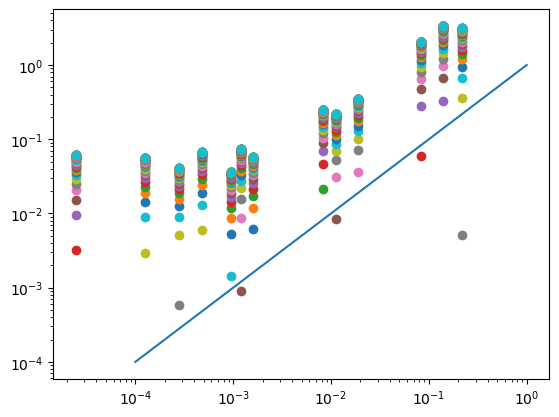

In [274]:
for M in np.logspace(5,10,100):
    plt.scatter(df_sel['D']/df_sel['N_emp'],(df_sel['count2_sum']/df['D']-df['D']/M-1))

plt.plot([1e-4,1e0],[1e-4,1e0])
plt.xscale('log')
plt.yscale('log')

In [ ]:
for N_emp in [1.1e7,1.1e8,1.1e9,1.1e10]:
    df_sel_sel = df_sel.query('N_emp == %s'%N_emp).sort_values('D')
    for i in range(len(df_sel_sel)):
        series = df_sel_sel.iloc[i]
        x = np.logspace(5,12,1000)
        plt.scatter(x, series['D'] / (series['count2_sum'] / series['D']- series['D']/x -1), marker='.', label='D = %.2e'%series['D'])
    plt.hlines(N_emp,1e5,1e12,color='black')
    plt.xlabel('M')
    plt.ylabel('N from F.F.')
    plt.xscale('log')
    plt.yscale('log')
    plt.legend()
    plt.show()

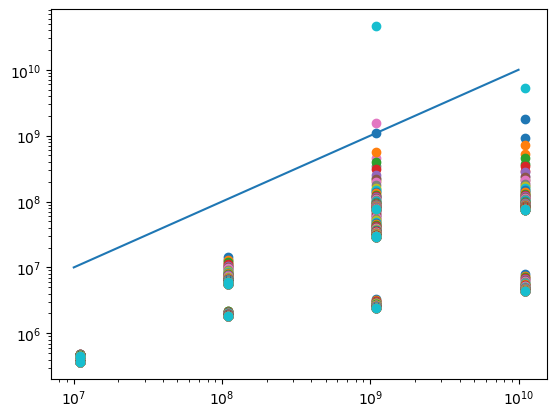

9931091.8137498

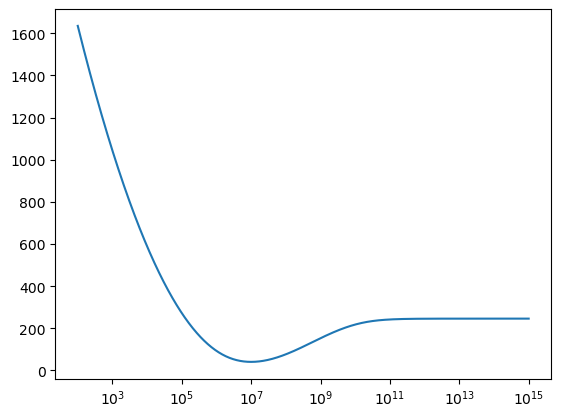

In [213]:
def mse(N_bott):
    mse_ = np.zeros(len(N_bott))
    for i in range(len(df)):
        N_emp = 1./(1./df.loc[i,'N_emp'] + 1./N_bott) 
        N_theo = df.loc[i,'D'] / (df.loc[i,'count2_sum']/df.loc[i,'D'] - df.loc[i,'D']/(20**7) - 1)
        #print(N_emp, N_theo)
        mse_ = mse_ + ((np.log(N_emp /N_theo))**2)
    return mse_

N_array = np.logspace(2,15,1000)
plt.semilogx(N_array, mse(N_array))
N_array[np.argmin(mse(N_array))]

85888285.59546258

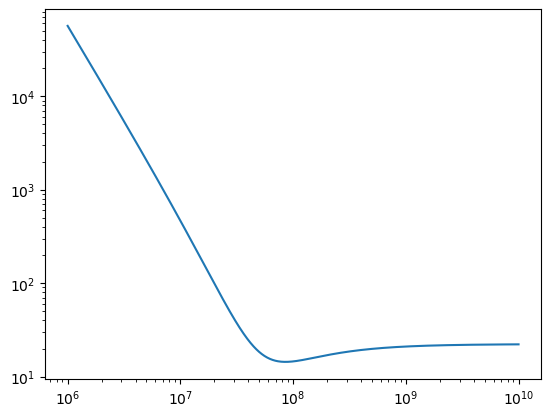

In [211]:
def mse_F(N_bott):
    mse_ = np.zeros(len(N_bott))
    for i in range(len(df)):
        F_emp = df.loc[i,'D']*(1./df.loc[i,'N_emp'] + 1./N_bott) 
        F_theo = (df.loc[i,'count2_sum']/df.loc[i,'D'] - df.loc[i,'D']/(20**7) - 1)
        #print(N_emp, N_theo)
        mse_ = mse_ + (F_emp - F_theo)**2
    return mse_

N_array = np.logspace(6,10,1000)
plt.loglog(N_array, mse_F(N_array))
N_array[np.argmin(mse_F(N_array))]

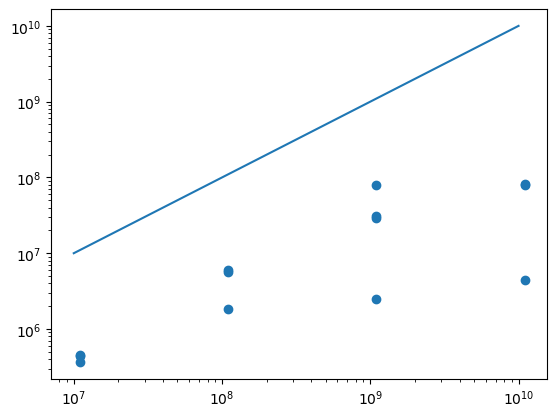

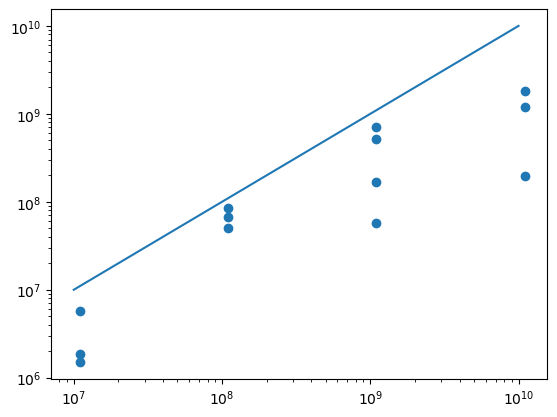

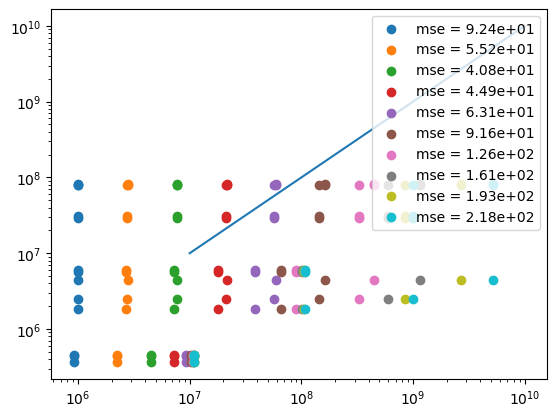

In [216]:
M = float(20**7)
N_theo = df['D'] / (df['count2_sum']/df['D'] - df['D']/M - 1)

plt.scatter(df['N_emp'],N_theo)
plt.plot([1e7,1e10],[1e7,1e10])
plt.xscale('log')
plt.yscale('log')
plt.title('')
plt.show()

M = df['unique_seqs'] + df['f1']**2 / (2*df['f2'])
N_theo = df['D'] / (df['count2_sum']/df['D'] - df['D']/M - 1)

plt.scatter(df['N_emp'],N_theo)
plt.plot([1e7,1e10],[1e7,1e10])
plt.xscale('log')
plt.yscale('log')
plt.title('')
plt.show()

for N_bot in np.logspace(6,10,10):
    M = float(20**7)
    N_theo = df['D'] / (df['count2_sum']/df['D'] - df['D']/M - 1)
    N_emp = 1./(1./df['N_emp'] + 1./N_bot)

    plt.scatter(N_emp,N_theo,label='mse = %.2e'%((np.log(N_theo/N_emp))**2).sum())
    
plt.plot([1e7,1e10],[1e7,1e10])
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.title('')
plt.show()

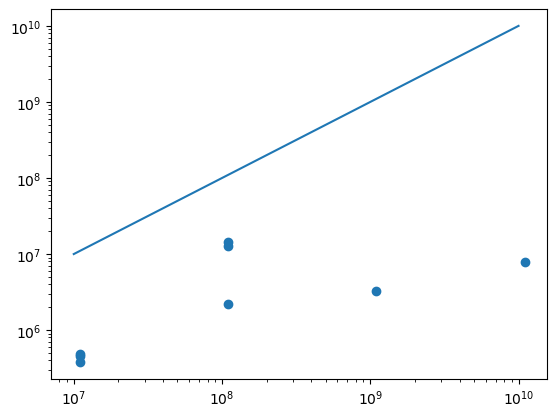

In [193]:
M = 1e7
N_theo = df['D'] / (df['count2_sum']/df['D'] - df['D']/M - 1)

plt.scatter(df['N_emp'],N_theo)
plt.plot([1e7,1e10],[1e7,1e10])
plt.xscale('log')
plt.yscale('log')
plt.title('')
plt.show()

In [159]:
data0 = pd.read_csv('../data_raw/TWIST_T0_cleaned.csv',delimiter=',', index_col=0)

data1 = pd.read_csv('../data_raw/TWIST_T0_100.counts',delimiter=' ', names=['seq','T0'],index_col=0)
#data1_ = pd.read_csv('../data_raw/IAKOV_83_S7_R1_001.counts',delimiter=' ', names=['seq','T0'],index_col=0)
#data1__ = pd.read_csv('../data_raw/IAKOV_83_S7_R2_001.counts',delimiter=' ', names=['seq','T0'],index_col=0)

data2 = pd.read_csv('../data_raw/TWIST_T0_10.counts',delimiter=' ', names=['seq','T0'],index_col=0)
#data2_ = pd.read_csv('../data_raw/IAKOV_84_S8_R1_001.counts',delimiter=' ', names=['seq','T0'],index_col=0)
#data2__ = pd.read_csv('../data_raw/IAKOV_84_S8_R2_001.counts',delimiter=' ', names=['seq','T0'],index_col=0)

data3 = pd.read_csv('../data_raw/TWIST_T0_1.counts',delimiter=' ', names=['seq','T0'], index_col=0)
#data3_ = pd.read_csv('../data_raw/IAKOV_85_S9_R1_001.counts',delimiter=' ', names=['seq','T0'],index_col=0)
#data3__ = pd.read_csv('../data_raw/IAKOV_85_S9_R2_001.counts',delimiter=' ', names=['seq','T0'],index_col=0)

data4 = pd.read_csv('../data_raw/TWIST_T0_01.counts',delimiter=' ', names=['seq','T0'], index_col=0)
#data4_ = pd.read_csv('../data_raw/IAKOV_86_S10_R1_001.counts',delimiter=' ', names=['seq','T0'],index_col=0)
#data4__ = pd.read_csv('../data_raw/IAKOV_86_S10_R2_001.counts',delimiter=' ', names=['seq','T0'],index_col=0)

In [175]:
df = pd.DataFrame(columns=['mean','variance','F-1','D','N_theo','N_emp'], index=range(5))
df_all = pd.DataFrame(columns=['mean','variance','F-1','D','N_theo','N_emp'], index=range(5))

In [176]:
data = data0
N = len(data) + len(data.query('T0 == 1')) ** 2 / (2*len(data.query('T0 == 2')))
df.loc[0,'mean'] = float(data.sum()) / N
df.loc[0,'variance'] = float((data**2).sum()) / N - (float(data.sum())/N)**2
df.loc[0,'D'] = int(data.sum())
N = 20**7
df_all.loc[0,'mean'] = float(data.sum()) / N
df_all.loc[0,'variance'] = float((data**2).sum()) / N - (float(data.sum())/N)**2
df_all.loc[0,'D'] = int(data.sum())

/tmp/ipykernel_727955/1141574328.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df.loc[0,'mean'] = float(data.sum()) / N
/tmp/ipykernel_727955/1141574328.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df.loc[0,'variance'] = float((data**2).sum()) / N - (float(data.sum())/N)**2
/tmp/ipykernel_727955/1141574328.py:5: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  df.loc[0,'D'] = int(data.sum())
/tmp/ipykernel_727955/1141574328.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df_all.loc[0,'mean'] = float(data.sum()) / N
/tmp/ipykernel_727955/1141574328.py:8: FutureWarning: Calling float on a 

In [177]:
data = data1
N = len(data) + len(data.query('T0 == 1')) ** 2 / (2*len(data.query('T0 == 2')))
df.loc[1,'mean'] = float(data.sum()) / N
df.loc[1,'variance'] = float((data**2).sum()) / N - (float(data.sum())/N)**2
df.loc[1,'D'] = int(data.sum())
N = 20**7
df_all.loc[1,'mean'] = float(data.sum()) / N
df_all.loc[1,'variance'] = float((data**2).sum()) / N - (float(data.sum())/N)**2
df_all.loc[1,'D'] = int(data.sum())

/tmp/ipykernel_727955/2200770572.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df.loc[1,'mean'] = float(data.sum()) / N
/tmp/ipykernel_727955/2200770572.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df.loc[1,'variance'] = float((data**2).sum()) / N - (float(data.sum())/N)**2
/tmp/ipykernel_727955/2200770572.py:5: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  df.loc[1,'D'] = int(data.sum())
/tmp/ipykernel_727955/2200770572.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df_all.loc[1,'mean'] = float(data.sum()) / N
/tmp/ipykernel_727955/2200770572.py:8: FutureWarning: Calling float on a 

In [178]:
data = data2
N = len(data) + len(data.query('T0 == 1')) ** 2 / (2*len(data.query('T0 == 2')))
df.loc[2,'mean'] = float(data.sum()) / N
df.loc[2,'variance'] = float((data**2).sum()) / N - (float(data.sum())/N)**2
df.loc[2,'D'] = int(data.sum())

N = 20**7
df_all.loc[2,'mean'] = float(data.sum()) / N
df_all.loc[2,'variance'] = float((data**2).sum()) / N - (float(data.sum())/N)**2
df_all.loc[2,'D'] = int(data.sum())

/tmp/ipykernel_727955/2212491223.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df.loc[2,'mean'] = float(data.sum()) / N
/tmp/ipykernel_727955/2212491223.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df.loc[2,'variance'] = float((data**2).sum()) / N - (float(data.sum())/N)**2
/tmp/ipykernel_727955/2212491223.py:5: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  df.loc[2,'D'] = int(data.sum())
/tmp/ipykernel_727955/2212491223.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df_all.loc[2,'mean'] = float(data.sum()) / N
/tmp/ipykernel_727955/2212491223.py:9: FutureWarning: Calling float on a 

In [179]:
data = data3
N = len(data) + len(data.query('T0 == 1')) ** 2 / (2*len(data.query('T0 == 2')))
df.loc[3,'mean'] = float(data.sum()) / N
df.loc[3,'variance'] = float((data**2).sum()) / N - (float(data.sum())/N)**2
df.loc[3,'D'] = int(data.sum())

N = 20**7
df_all.loc[3,'mean'] = float(data.sum()) / N
df_all.loc[3,'variance'] = float((data**2).sum()) / N - (float(data.sum())/N)**2
df_all.loc[3,'D'] = int(data.sum())

/tmp/ipykernel_727955/3217589850.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df.loc[3,'mean'] = float(data.sum()) / N
/tmp/ipykernel_727955/3217589850.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df.loc[3,'variance'] = float((data**2).sum()) / N - (float(data.sum())/N)**2
/tmp/ipykernel_727955/3217589850.py:5: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  df.loc[3,'D'] = int(data.sum())
/tmp/ipykernel_727955/3217589850.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df_all.loc[3,'mean'] = float(data.sum()) / N
/tmp/ipykernel_727955/3217589850.py:9: FutureWarning: Calling float on a 

In [180]:
data = data4
N = len(data) + len(data.query('T0 == 1')) ** 2 / (2*len(data.query('T0 == 2')))
df.loc[4,'mean'] = float(data.sum()) / N
df.loc[4,'variance'] = float((data**2).sum()) / N - (float(data.sum())/N)**2
df.loc[4,'D'] = int(data.sum())

N = 20**7
df_all.loc[4,'mean'] = float(data.sum()) / N
df_all.loc[4,'variance'] = float((data**2).sum()) / N - (float(data.sum())/N)**2
df_all.loc[4,'D'] = int(data.sum())

/tmp/ipykernel_727955/1070846864.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df.loc[4,'mean'] = float(data.sum()) / N
/tmp/ipykernel_727955/1070846864.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df.loc[4,'variance'] = float((data**2).sum()) / N - (float(data.sum())/N)**2
/tmp/ipykernel_727955/1070846864.py:5: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  df.loc[4,'D'] = int(data.sum())
/tmp/ipykernel_727955/1070846864.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df_all.loc[4,'mean'] = float(data.sum()) / N
/tmp/ipykernel_727955/1070846864.py:9: FutureWarning: Calling float on a 

In [181]:
df['F-1'] = df['variance'] / df['mean'] - 1
df['N_theo'] = df['D'] / df['F-1']
df['N_emp'] = [10,100,10,1,0.1]#[10,100,100,100,10,10,10,1,1,1,0.1,0.1,0.1]
df['N_emp'] = df['N_emp'] * 1.1e8

df_all['F-1'] = df_all['variance'] / df_all['mean'] - 1
df_all['N_theo'] = df_all['D'] / df_all['F-1']
df_all['N_emp'] = [10,100,10,1,0.1]#[10,100,100,100,10,10,10,1,1,1,0.1,0.1,0.1]
df_all['N_emp'] = df_all['N_emp'] * 1.1e8

In [182]:
df.to_csv('df_N.csv')

In [183]:
df_all

,mean,variance,F-1,D,N_theo,N_emp
0,0.18792,0.75112,2.997025,240537189,80258644.390061,1.100000e+09
1,0.000212,0.000225,0.061374,270877,4413580.622575,1.100000e+10
2,0.000109,0.000115,0.056607,139501,2464357.425868,1.100000e+09
3,0.000103,0.00011,0.072789,131784,1810492.128739,1.100000e+08
4,0.000071,0.000089,0.246967,90990,368429.715443,1.100000e+07


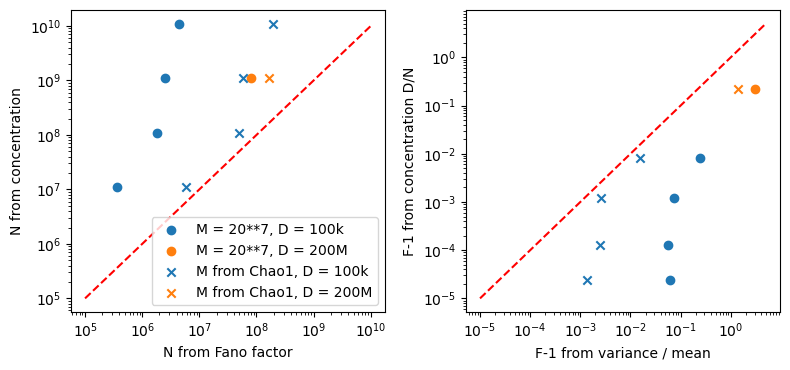

In [184]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,3.8),facecolor='white')

plt.subplot(1,2,1)
plt.scatter(df_all.query('D < 1000000')['N_theo'], df.query('D < 1000000')['N_emp'], label='M = 20**7, D = 100k')
plt.scatter(df_all.query('D > 1000000')['N_theo'], df.query('D > 1000000')['N_emp'], label='M = 20**7, D = 200M')
plt.scatter(df.query('D < 1000000')['N_theo'], df.query('D < 1000000')['N_emp'], label='M from Chao1, D = 100k', marker='x', color='C0')
plt.scatter(df.query('D > 1000000')['N_theo'], df.query('D > 1000000')['N_emp'], label='M from Chao1, D = 200M', marker='x', color='C1')
plt.plot([1e5,1e10],[1e5,1e10],color='red',linestyle='--')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('N from Fano factor')
plt.ylabel('N from concentration')
plt.legend()

plt.subplot(1,2,2)
plt.scatter(df_all.query('D < 1000000')['F-1'], df.query('D < 1000000')['D'] / df.query('D < 1000000')['N_emp'], label='M = 20**7, D = 100k')
plt.scatter(df_all.query('D > 1000000')['F-1'], df.query('D > 1000000')['D'] / df.query('D > 1000000')['N_emp'], label='M = 20**7, D = 200M')
plt.scatter(df.query('D < 1000000')['F-1'], df.query('D < 1000000')['D'] / df.query('D < 1000000')['N_emp'], label='M from Chao1, D = 100k', marker='x', color='C0')
plt.scatter(df.query('D > 1000000')['F-1'], df.query('D > 1000000')['D'] / df.query('D > 1000000')['N_emp'], label='M from Chao1, D = 200M', marker='x', color='C1')
plt.plot([1e-5,5],[1e-5,5],color='red',linestyle='--')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('F-1 from variance / mean')
plt.ylabel('F-1 from concentration D/N')

plt.tight_layout()
plt.savefig('N_plot.png')

In [185]:
df = df.astype('float')

In [186]:
def error(x, df):
    return (((df['F-1']) - (df['D']*(1/x + 1/df['N_emp'])))**2).sum()

error_vector = []
error_vector_all = []
N_vector = np.logspace(7,10,1000)

for N in N_vector:
    error_vector.append(error(N, df))
    error_vector_all.append(error(N, df_all))

Nt = N_vector[np.argmin(error_vector)]
Nt_all = N_vector[np.argmin(error_vector_all)]

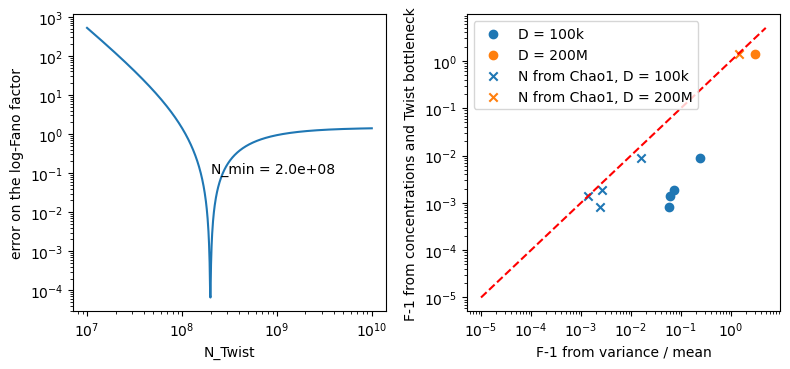

In [187]:
plt.figure(figsize=(8,3.8),facecolor='white')

plt.subplot(1,2,1)
plt.loglog(N_vector, error_vector)
plt.text(2e8,1e-1,'N_min = %.1e'%Nt)
plt.xlabel('N_Twist')
plt.ylabel('error on the log-Fano factor')

plt.subplot(1,2,2)
plt.scatter(df_all.query('D < 1000000')['F-1'], df_all.query('D < 1000000')['D'] *(1/Nt +1 / df.query('D < 1000000')['N_emp']), label='D = 100k')
plt.scatter(df_all.query('D > 1000000')['F-1'], df_all.query('D > 1000000')['D'] *(1/Nt +1 / df.query('D > 1000000')['N_emp']), label='D = 200M')
plt.scatter(df.query('D < 1000000')['F-1'], df.query('D < 1000000')['D'] *(1/Nt +1 / df.query('D < 1000000')['N_emp']), label='N from Chao1, D = 100k', marker='x', color='C0')
plt.scatter(df.query('D > 1000000')['F-1'], df.query('D > 1000000')['D'] *(1/Nt +1 / df.query('D > 1000000')['N_emp']), label='N from Chao1, D = 200M', marker='x', color='C1')
plt.plot([1e-5,5],[1e-5,5],color='red',linestyle='--')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('F-1 from variance / mean')
plt.ylabel('F-1 from concentrations and Twist bottleneck')
plt.legend()

plt.tight_layout()
plt.savefig('N_plot.png')